<a href="https://colab.research.google.com/github/suryamanoj4/SMAI-Assignment-2/blob/main/SMAI_assign_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Q1**
Bike Rental Demand Prediction with Linear Regression

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib

from sklearn.model_selection import train_test_split

username = "manoj.pentakota"
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)

df = pd.read_csv("/content/hour.csv")

print("Dataset shapeL:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

display(df.tail())

print(df.dtypes)

Dataset shapeL: (17379, 17)

Columns:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61
17378,17379,2012-12-31,1,1,12,23,0,1,1,1,0.26,0.2727,0.65,0.1343,12,37,49


instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


In [69]:
TARGET="cnt"

DROP_COLUMNS= ["cnt","casual","registered","instant","dteday"]

x_raw = df.drop(columns=DROP_COLUMNS)
y_raw = df[TARGET]

print(x_raw.shape)
print(x_raw.columns.tolist())

(17379, 12)
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']


In [70]:
#one hot encoding
categorial_features = ["season",'mnth',"hr","holiday","weekday","weathersit"]
continuos_features = ["temp","atemp","hum","windspeed"]

x_base = x_raw.drop(columns=["workingday"])

x_encoded = pd.get_dummies(
    x_base, columns=categorial_features, drop_first=True, dtype=float
)
print("shape after encoding:", x_encoded.shape)
print("\nencoded feature columns")
print(x_encoded.columns.tolist())

shape after encoding: (17379, 52)

encoded feature columns
['yr', 'temp', 'atemp', 'hum', 'windspeed', 'season_2', 'season_3', 'season_4', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'hr_1', 'hr_2', 'hr_3', 'hr_4', 'hr_5', 'hr_6', 'hr_7', 'hr_8', 'hr_9', 'hr_10', 'hr_11', 'hr_12', 'hr_13', 'hr_14', 'hr_15', 'hr_16', 'hr_17', 'hr_18', 'hr_19', 'hr_20', 'hr_21', 'hr_22', 'hr_23', 'holiday_1', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'weathersit_2', 'weathersit_3', 'weathersit_4']


hr, mnth, weekday, season, holiday, and weathersit were treated as categorical variables and one-hot encoded. workingday was excluded as a standalone feature because of an exact linear dependency with the weekday/holiday representation, but it was retained in the selected interaction terms.

In [71]:
#interaction terms

x_engineered=x_encoded.copy()

#morning rush hour + clear weather
x_engineered["hr8_weather1"] = ((x_raw["hr"] == 8)&(x_raw["weathersit"] == 1)).astype(float)

#evening rush hour + clear weather
x_engineered["hr17_weather1"] = ((x_raw["hr"] == 17)&(x_raw["weathersit"] == 1)).astype(float)

#morning rush hour + working day
x_engineered["hr8_workingday"] = ((x_raw["hr"] == 8)&(x_raw["workingday"] == 1)).astype(float)

#evening rush hour + working day
x_engineered["hr17_workingday"] = ((x_raw["hr"] == 17)&(x_raw["workingday"] == 1)).astype(float)

#mid day + moderate weather
x_engineered["hr12_weather2"] = ((x_raw["hr"] == 12)&(x_raw["weathersit"] == 2)).astype(float)

print("Interaction columns:\n")
print(
    [
        col for col in x_engineered.columns
    ]
)

Interaction columns:

['yr', 'temp', 'atemp', 'hum', 'windspeed', 'season_2', 'season_3', 'season_4', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'hr_1', 'hr_2', 'hr_3', 'hr_4', 'hr_5', 'hr_6', 'hr_7', 'hr_8', 'hr_9', 'hr_10', 'hr_11', 'hr_12', 'hr_13', 'hr_14', 'hr_15', 'hr_16', 'hr_17', 'hr_18', 'hr_19', 'hr_20', 'hr_21', 'hr_22', 'hr_23', 'holiday_1', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'weathersit_2', 'weathersit_3', 'weathersit_4', 'hr8_weather1', 'hr17_weather1', 'hr8_workingday', 'hr17_workingday', 'hr12_weather2']


In [72]:
print("Final design matrix before normalization:")
print("Rows:", x_engineered.shape[0])
print("Columns:", x_engineered.shape[1])

print("\nData types:")
print(x_engineered.dtypes.value_counts())

Final design matrix before normalization:
Rows: 17379
Columns: 57

Data types:
float64    56
int64       1
Name: count, dtype: int64


In [73]:
#train test split

x_train,x_temp,y_train,y_temp = train_test_split(
    x_engineered,y_raw,test_size=0.2,random_state=seed
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, random_state=seed
)

print("Training set:", x_train.shape, y_train.shape)
print("Validation set:", x_val.shape, y_val.shape)
print("Test set:", x_test.shape, y_test.shape)

Training set: (13903, 57) (13903,)
Validation set: (1738, 57) (1738,)
Test set: (1738, 57) (1738,)


In [74]:
# continuos features normalization

train_means = x_train[continuos_features].mean()
train_stds = x_train[continuos_features].std()

print("training means:")
print(train_means)
print("\ntraining stds:")
print(train_stds)

x_train_scaled = x_train.copy()
x_val_scaled = x_val.copy()
x_test_scaled = x_test.copy()

for col in continuos_features:
  x_train_scaled[col] = (x_train[col]-train_means[col])/train_stds[col]
  x_val_scaled[col] = (x_val[col]-train_means[col])/train_stds[col]
  x_test_scaled[col] = (x_test[col]-train_means[col])/train_stds[col]

print("training means after standardization:")
print(x_train_scaled[continuos_features].mean())
print("\ntraining stds after standardization:")
print(x_train_scaled[continuos_features].std())

training means:
temp         0.496663
atemp        0.475378
hum          0.627263
windspeed    0.190794
dtype: float64

training stds:
temp         0.192628
atemp        0.171966
hum          0.193157
windspeed    0.122585
dtype: float64
training means after standardization:
temp        -2.494029e-16
atemp        2.770008e-16
hum          1.773418e-16
windspeed    1.341563e-16
dtype: float64

training stds after standardization:
temp         1.0
atemp        1.0
hum          1.0
windspeed    1.0
dtype: float64


In [75]:
x_train_np = x_train_scaled.to_numpy()
x_val_np = x_val_scaled.to_numpy()
x_test_np = x_test_scaled.to_numpy()

print("x_train:", x_train_np.shape)
print("x_val:", x_val_np.shape)
print("x_test:", x_test_np.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

x_train: (13903, 57)
x_val: (1738, 57)
x_test: (1738, 57)
y_train: (13903,)
y_val: (1738,)
y_test: (1738,)


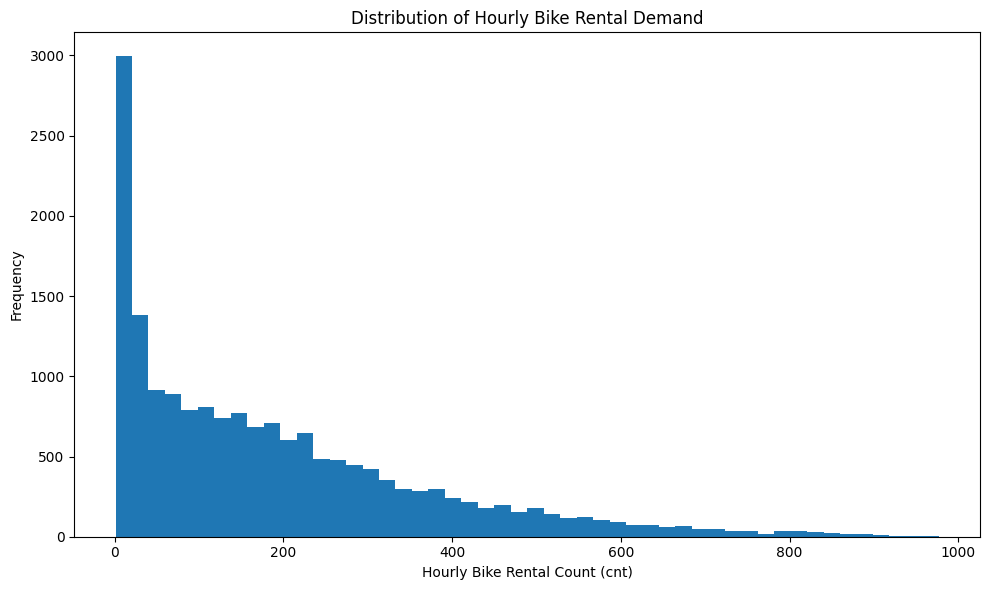

In [76]:
#visualizations
#distribution of cnt

plt.figure(figsize=(10, 6))
plt.hist(df["cnt"], bins=50)
plt.xlabel("Hourly Bike Rental Count (cnt)")
plt.ylabel("Frequency")
plt.title("Distribution of Hourly Bike Rental Demand")
plt.tight_layout()
plt.show()

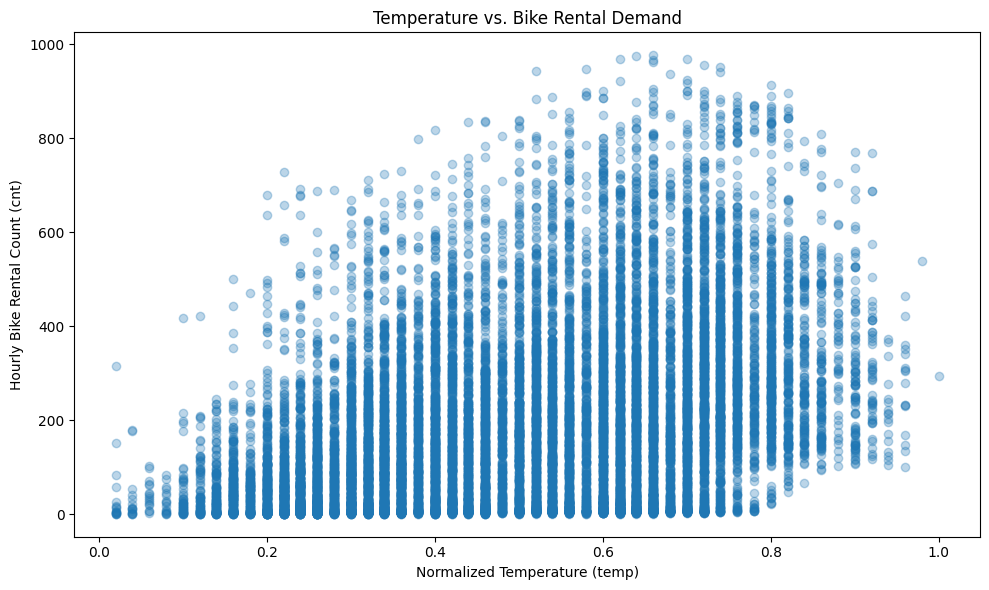

In [77]:
#Temperature vs target

plt.figure(figsize=(10, 6))
plt.scatter(
    df["temp"],
    df["cnt"],
    alpha=0.3
)
plt.xlabel("Normalized Temperature (temp)")
plt.ylabel("Hourly Bike Rental Count (cnt)")
plt.title("Temperature vs. Bike Rental Demand")
plt.tight_layout()
plt.show()

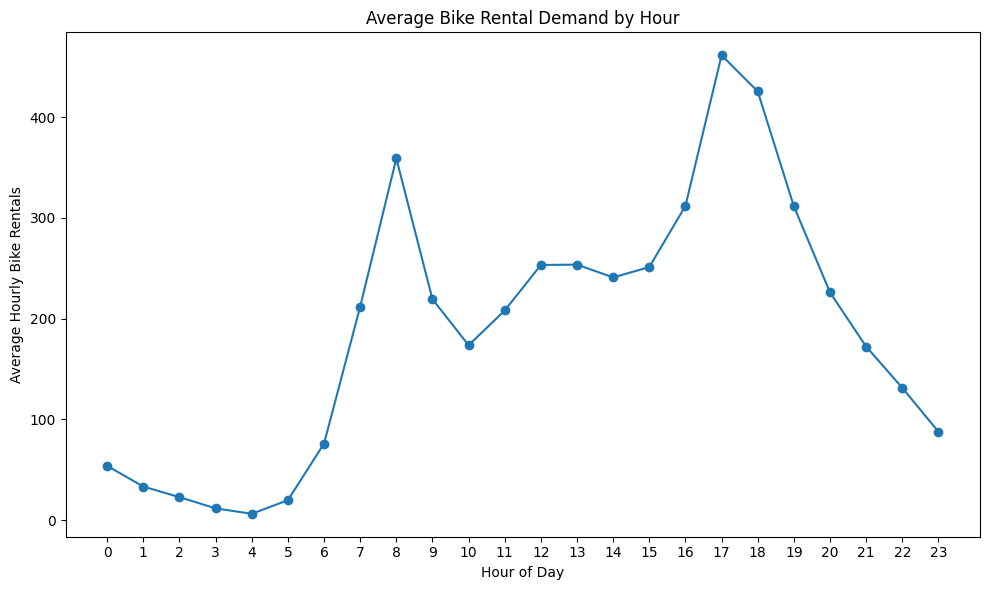

In [78]:
# Hour of day vs target

hourly_demand = df.groupby("hr")["cnt"].mean()
plt.figure(figsize=(10, 6))
plt.plot(
    hourly_demand.index,
    hourly_demand.values,
    marker="o"
)
plt.xlabel("Hour of Day")
plt.ylabel("Average Hourly Bike Rentals")
plt.title("Average Bike Rental Demand by Hour")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

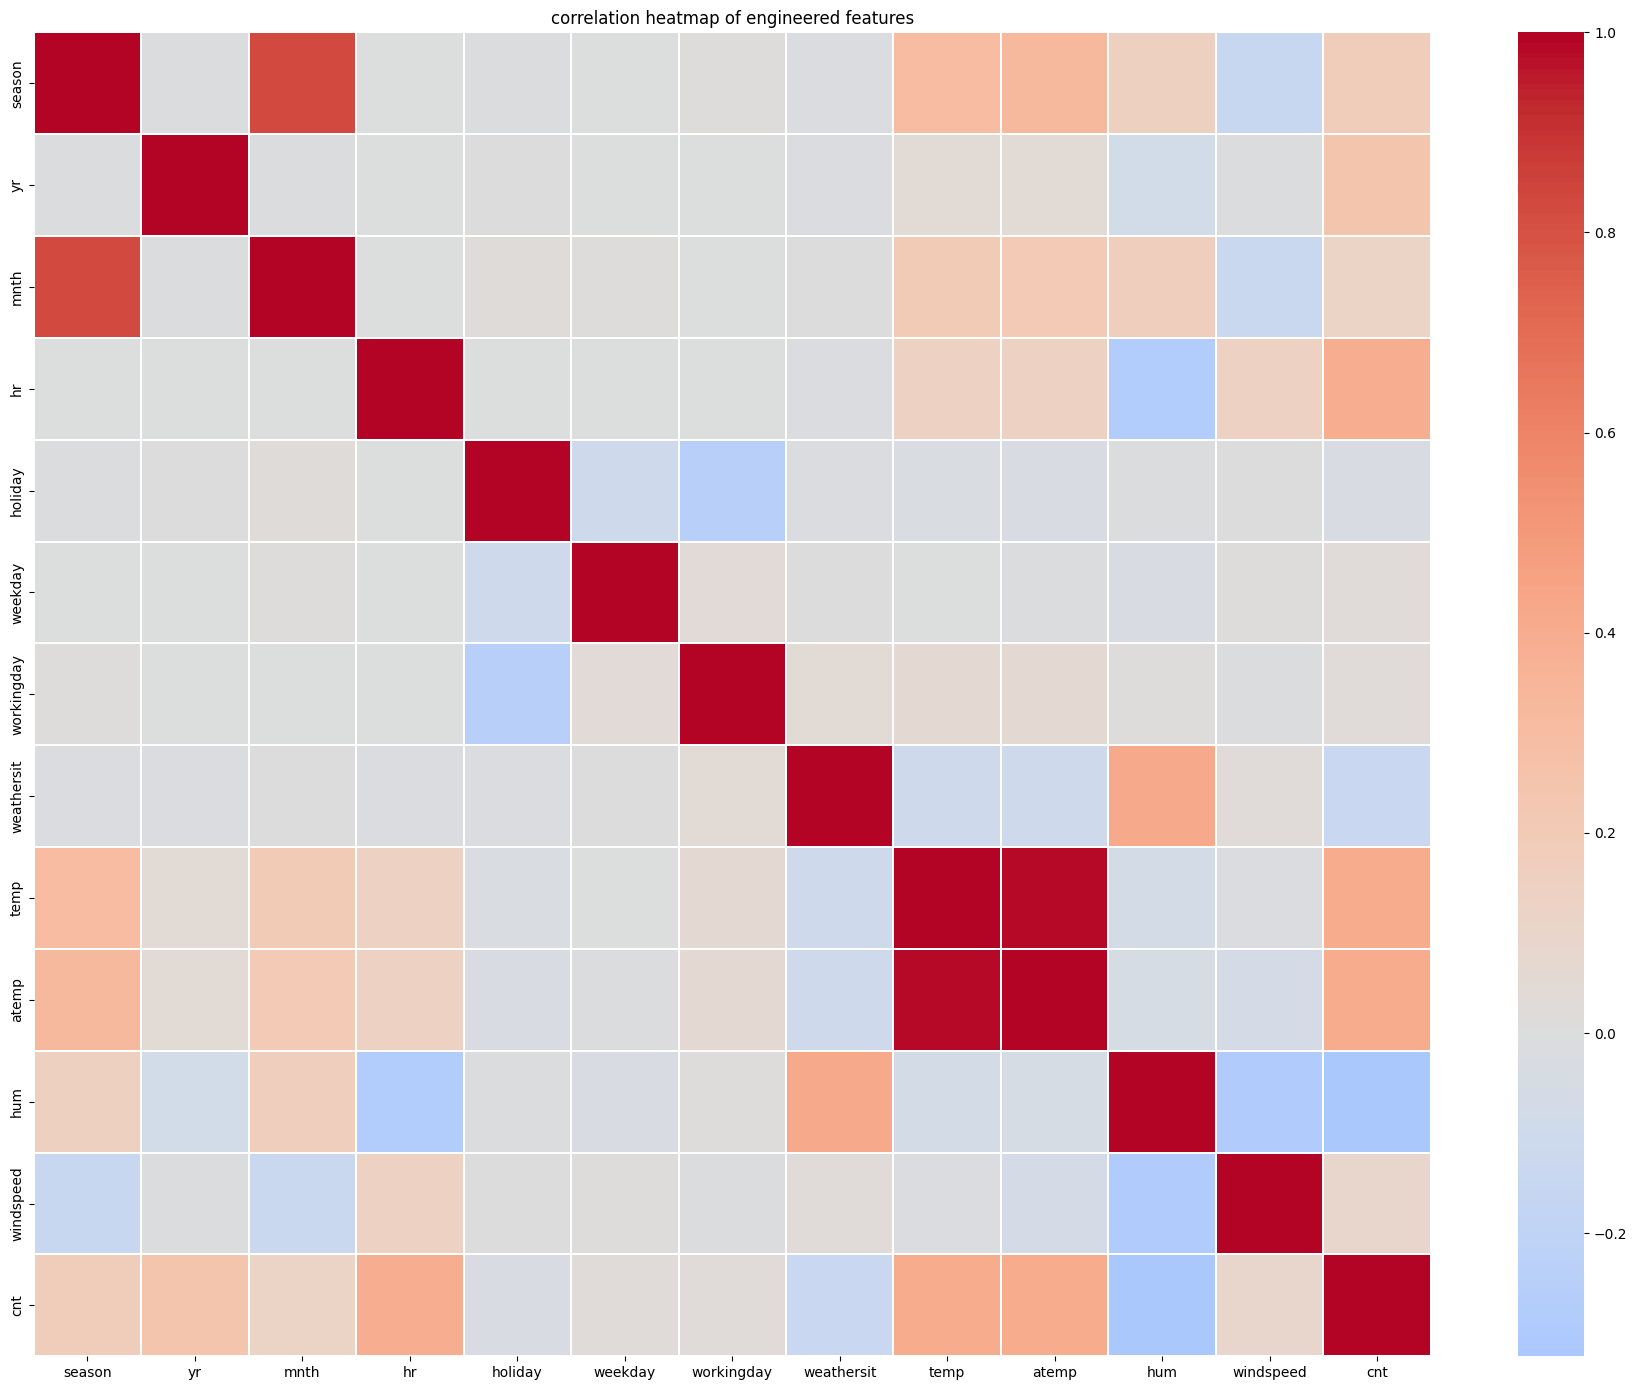

In [79]:
correlation_columns = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit",
    "temp",
    "atemp",
    "hum",
    "windspeed",
    "cnt"
]
correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(18,14))
sns.heatmap(correlation_matrix,cmap="coolwarm",center=0,linewidths=0.2)
plt.title("correlation heatmap of engineered features")
plt.tight_layout()
plt.show()

In [80]:
# Compare raw integer hr vs one-hot encoded hr

def build_q11_features(hr_encoding="onehot"):
    x_base = x_raw.drop(columns=["workingday"]).copy()
    categorical_features = [
        "season",
        "mnth",
        "holiday",
        "weekday",
        "weathersit"
    ]
    # Encode hr only for the one-hot model
    if hr_encoding == "onehot":
        categorical_features.append("hr")
    x_features = pd.get_dummies(
        x_base,
        columns=categorical_features,
        drop_first=True,
        dtype=float
    )
    # Same five interaction terms for both models
    x_features["hr8_weather1"] = (
        (x_raw["hr"] == 8) &
        (x_raw["weathersit"] == 1)
    ).astype(float)
    x_features["hr17_weather1"] = (
        (x_raw["hr"] == 17) &
        (x_raw["weathersit"] == 1)
    ).astype(float)
    x_features["hr8_workingday"] = (
        (x_raw["hr"] == 8) &
        (x_raw["workingday"] == 1)
    ).astype(float)
    x_features["hr17_workingday"] = (
        (x_raw["hr"] == 17) &
        (x_raw["workingday"] == 1)
    ).astype(float)
    x_features["hr12_weather2"] = (
        (x_raw["hr"] == 12) &
        (x_raw["weathersit"] == 2)
    ).astype(float)
    return x_features


x_q11_onehot = build_q11_features("onehot")
x_q11_raw = build_q11_features("raw")

print("One-hot hr shape:", x_q11_onehot.shape)
print("Raw hr shape:", x_q11_raw.shape)

One-hot hr shape: (17379, 57)
Raw hr shape: (17379, 35)


In [81]:
# Reuse the exact same train/validation split

train_idx = x_train.index
val_idx = x_val.index
x_onehot_train = x_q11_onehot.loc[train_idx].copy()
x_onehot_val = x_q11_onehot.loc[val_idx].copy()
x_raw_train = x_q11_raw.loc[train_idx].copy()
x_raw_val = x_q11_raw.loc[val_idx].copy()

In [82]:
# Standardize continuous features using training statistics

q11_means = x_onehot_train[continuos_features].mean()
q11_stds = x_onehot_train[continuos_features].std()
for data in [x_onehot_train, x_onehot_val, x_raw_train, x_raw_val]:
    data[continuos_features] = (
        data[continuos_features] - q11_means
    ) / q11_stds

In [83]:
x_onehot_train_np = x_onehot_train.to_numpy(dtype=float)
x_onehot_val_np = x_onehot_val.to_numpy(dtype=float)

x_raw_train_np = x_raw_train.to_numpy(dtype=float)
x_raw_val_np = x_raw_val.to_numpy(dtype=float)

# Add intercept
x_onehot_train_np = np.column_stack([
    np.ones(x_onehot_train_np.shape[0]),
    x_onehot_train_np
])
x_onehot_val_np = np.column_stack([
    np.ones(x_onehot_val_np.shape[0]),
    x_onehot_val_np
])
x_raw_train_np = np.column_stack([
    np.ones(x_raw_train_np.shape[0]),
    x_raw_train_np
])
x_raw_val_np = np.column_stack([
    np.ones(x_raw_val_np.shape[0]),
    x_raw_val_np
])

In [84]:
def predict_linear_regression(x, weights):
  return x @ weights

def rmse(y_true,y_pred):
  return np.sqrt(np.mean((y_true-y_pred)**2))

In [85]:
# Normal Equation (closed form)

def normal_equation(x, y):
    return np.linalg.solve(x.T @ x, x.T @ y)

# Fit raw-hour model
weights_raw_hr = normal_equation(
    x_raw_train_np,
    y_train.to_numpy()
)

# Fit one-hot-hour model
weights_onehot_hr = normal_equation(
    x_onehot_train_np,
    y_train.to_numpy()
)

In [86]:
# Predictions
y_val_pred_raw_hr = predict_linear_regression(
    x_raw_val_np,
    weights_raw_hr
)
y_val_pred_onehot_hr = predict_linear_regression(
    x_onehot_val_np,
    weights_onehot_hr
)
# Validation RMSE
rmse_raw_hr = rmse(
    y_val.to_numpy(),
    y_val_pred_raw_hr
)
rmse_onehot_hr = rmse(
    y_val.to_numpy(),
    y_val_pred_onehot_hr
)
print("Raw hr validation RMSE:", rmse_raw_hr)
print("One-hot hr validation RMSE:", rmse_onehot_hr)

Raw hr validation RMSE: 119.71241606706211
One-hot hr validation RMSE: 93.09531545971274


In [87]:
print("\nHour Representation Comparison")
print("-" * 50)

print(f"Raw integer hr     : {rmse_raw_hr:.4f}")
print(f"One-hot encoded hr : {rmse_onehot_hr:.4f}")

print(f"\nRMSE improvement from one-hot: "
      f"{rmse_raw_hr - rmse_onehot_hr:.4f}")

print("\nDesign matrix columns:")
print("Raw hr model:", x_q11_raw.shape[1])
print("One-hot hr model:", x_q11_onehot.shape[1])


Hour Representation Comparison
--------------------------------------------------
Raw integer hr     : 119.7124
One-hot encoded hr : 93.0953

RMSE improvement from one-hot: 26.6171

Design matrix columns:
Raw hr model: 35
One-hot hr model: 57


In [88]:
# continue with the 1.3 implementations after the 1.1 ablation study
# add a column of ones for the intercept / bias

x_train = np.column_stack([np.ones(x_train_np.shape[0]), x_train_np])
x_val = np.column_stack([np.ones(x_val_np.shape[0]), x_val_np])
x_test = np.column_stack([np.ones(x_test_np.shape[0]), x_test_np])

print("new x_train shape:", x_train.shape)
print("new x_val shape:", x_val.shape)
print("new x_test shape:", x_test.shape)

new x_train shape: (13903, 58)
new x_val shape: (1738, 58)
new x_test shape: (1738, 58)


In [89]:
#conditional numbers for matrix x and x^t x

condition_x = np.linalg.cond(x_train)
xtx = x_train.T @ x_train
condition_xtx = np.linalg.cond(xtx)

print("Condition number of x:", condition_x)
print("Condition number of x^T x:", condition_xtx)

Condition number of x: 100.4324685424116
Condition number of x^T x: 10086.68073752245


Here for the conditional numbers at first we have got a really massive number and open inspection found the features matrix is 58 in dimentions(features) but its rank is 5 which means there is 1 directly linear dependency and by furthur inspection found that aput by feature design the column workingday is highly irrelevant and linear dependent due to the weekday giving a more granular info but working still gives the treand info so it is being ussed in the interactiove features

In [90]:
#closed form solution
# beta = (X^T * X)^-1 * X^T * y

xtx = x_train.T @ x_train
xty = x_train.T @ y_train
beta_closed = np.linalg.inv(xtx) @ xty

print("Number of weights:", len(beta_closed))
print("First 10 weights:")
print(beta_closed[:10])

Number of weights: 58
First 10 weights:
[ -8.45410843  85.1432644   21.53013566  21.04961102 -15.39045833
  -3.52061154  37.49326446  29.64309858  66.84237699   3.99397815]


In [91]:
y_train_pred_closed = predict_linear_regression(x_train, beta_closed)
train_rmse_closed = rmse(y_train, y_train_pred_closed)
print("closed form training RMSE:", train_rmse_closed)

y_val_pred_closed = predict_linear_regression(x_val, beta_closed)
val_rmse_closed = rmse(y_val, y_val_pred_closed)
print("closed form validation RMSE:", val_rmse_closed)

closed form training RMSE: 93.06860957469993
closed form validation RMSE: 93.09531545971272


In [92]:
# Standardization and learning rate ablation

# Unstandardized data:
# x_train and x_val already contain the intercept
x_train_unscaled_np = x_train.copy()
x_val_unscaled_np = x_val.copy()

# Standardized data:
# x_train_scaled and x_val_scaled do not contain the intercept
x_train_standardized_np = x_train_scaled.to_numpy(dtype=float)
x_val_standardized_np = x_val_scaled.to_numpy(dtype=float)

# Add intercept to standardized data
x_train_standardized_np = np.column_stack([
    np.ones(x_train_standardized_np.shape[0]),
    x_train_standardized_np
])

x_val_standardized_np = np.column_stack([
    np.ones(x_val_standardized_np.shape[0]),
    x_val_standardized_np
])

print("Unstandardized training:", x_train_unscaled_np.shape)
print("Standardized training:", x_train_standardized_np.shape)

Unstandardized training: (13903, 58)
Standardized training: (13903, 58)


In [93]:
#Gradient Descent approach

def batch_gradient_descent(x,y,learning_rate=0.01,max_iterations=1000,tolerance=1e-8):
  n_samples, n_features = x.shape
  weights = np.zeros(n_features) #initialize weights
  loss_history = []
  for iteration in range(max_iterations):
    predictions = x @ weights
    error = predictions - y
    loss = np.mean(error**2)/2
    loss_history.append(loss)
    gradient = (x.T @ error)/n_samples
    new_weights = weights - learning_rate * gradient
    if tolerance is not None:
      if np.linalg.norm(new_weights - weights) < tolerance:
        weights = new_weights
        break
    weights = new_weights
  return  weights, loss_history, iteration + 1

In [94]:
#learning rate ablation

learning_rates = [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1.0]

max_iterations_ablation = 1000
results_unstandardized = {}
results_standardized = {}
y_train_np = y_train.to_numpy()
y_val_np = y_val.to_numpy()
for lr in learning_rates:
    # Unstandardized
    weights_unscaled, loss_unscaled, iterations_unscaled = (
        batch_gradient_descent(
            x_train_unscaled_np,
            y_train_np,
            learning_rate=lr,
            max_iterations=max_iterations_ablation,
            tolerance=None
        )
    )
    # Standardized
    weights_scaled, loss_scaled, iterations_scaled = (
        batch_gradient_descent(
            x_train_standardized_np,
            y_train_np,
            learning_rate=lr,
            max_iterations=max_iterations_ablation,
            tolerance=None
        )
    )
    results_unstandardized[lr] = {
        "weights": weights_unscaled,
        "loss": loss_unscaled
    }
    results_standardized[lr] = {
        "weights": weights_scaled,
        "loss": loss_scaled
    }
print("Learning-rate experiments completed.")

Learning-rate experiments completed.


In [95]:
def check_stability(loss_history):

    loss_history = np.asarray(loss_history)
    if not np.all(np.isfinite(loss_history)):
        return False
    if loss_history[-1] > loss_history[0] * 100:
        return False
    if loss_history[-1] >= loss_history[0]:
        return False

    return True

print("Unstandardized learning rates:")
for lr in learning_rates:
    stable = check_stability(results_unstandardized[lr]["loss"])
    print(f"LR = {lr:<7} Stable = {stable}")

print("\nStandardized learning rates:")
for lr in learning_rates:
    stable = check_stability(results_standardized[lr]["loss"])
    print(f"LR = {lr:<7} Stable = {stable}")

Unstandardized learning rates:
LR = 1e-05   Stable = True
LR = 0.0001  Stable = True
LR = 0.001   Stable = True
LR = 0.01    Stable = True
LR = 0.1     Stable = True
LR = 1.0     Stable = False

Standardized learning rates:
LR = 1e-05   Stable = True
LR = 0.0001  Stable = True
LR = 0.001   Stable = True
LR = 0.01    Stable = True
LR = 0.1     Stable = True
LR = 1.0     Stable = False


In [96]:
stable_unstandardized = [
    lr for lr in learning_rates
    if check_stability(results_unstandardized[lr]["loss"])
]
stable_standardized = [
    lr for lr in learning_rates
    if check_stability(results_standardized[lr]["loss"])
]
largest_stable_unstandardized = (
    max(stable_unstandardized)
    if stable_unstandardized else None
)
largest_stable_standardized = (
    max(stable_standardized)
    if stable_standardized else None
)
print("Largest stable LR without standardization:",
      largest_stable_unstandardized)
print("Largest stable LR with standardization:",
      largest_stable_standardized)

Largest stable LR without standardization: 0.1
Largest stable LR with standardization: 0.1


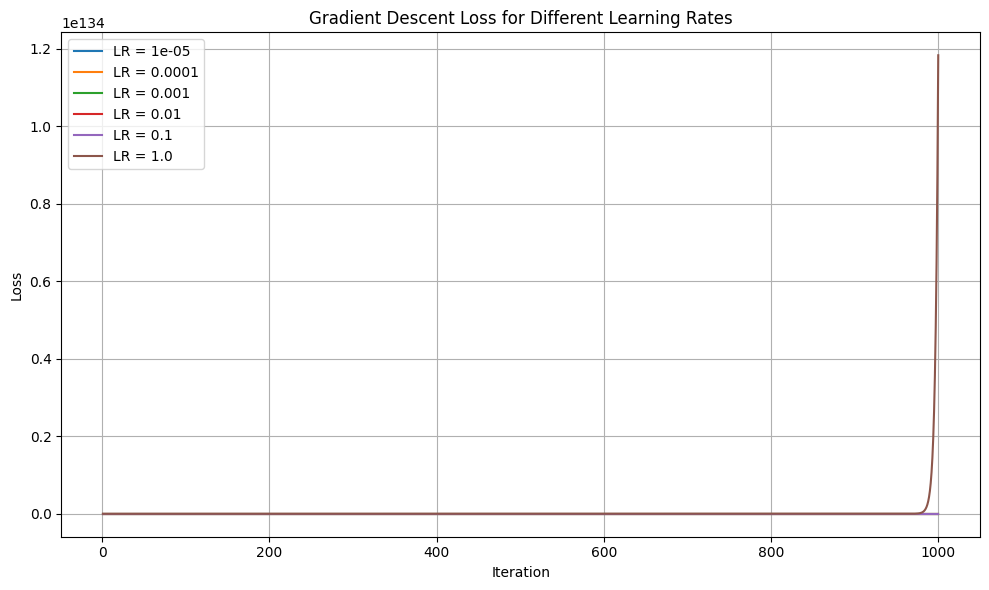

In [97]:
plt.figure(figsize=(10, 6))

for lr in learning_rates:
    loss_history = results_standardized[lr]["loss"]

    plt.plot(
        range(1, len(loss_history) + 1),
        loss_history,
        label=f"LR = {lr}"
    )

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Gradient Descent Loss for Different Learning Rates")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [98]:
common_stable_lrs = sorted(
    set(stable_unstandardized) &
    set(stable_standardized)
)

print("Learning rates stable for both:")
print(common_stable_lrs)

Learning rates stable for both:
[1e-05, 0.0001, 0.001, 0.01, 0.1]


In [99]:
if common_stable_lrs:

    common_lr = max(common_stable_lrs)
    print("Largest learning rate stable for both:", common_lr)
    # Run until convergence
    weights_unscaled_conv, loss_unscaled_conv, iterations_unscaled_conv = (
        batch_gradient_descent(
            x_train_unscaled_np,
            y_train_np,
            learning_rate=common_lr,
            max_iterations=50000,
            tolerance=1e-8
        )
    )
    weights_scaled_conv, loss_scaled_conv, iterations_scaled_conv = (
        batch_gradient_descent(
            x_train_standardized_np,
            y_train_np,
            learning_rate=common_lr,
            max_iterations=50000,
            tolerance=1e-8
        )
    )
    print(
        "\nIterations to converge without standardization:",
        iterations_unscaled_conv
    )
    print(
        "Iterations to converge with standardization:",
        iterations_scaled_conv
    )
else:
    print("No common stable learning rate found.")

Largest learning rate stable for both: 0.1

Iterations to converge without standardization: 50000
Iterations to converge with standardization: 50000


In [103]:
gd_weights, loss_history, gd_iterations = batch_gradient_descent(
    x_train,
    y_train,
    learning_rate=0.01,
    max_iterations=50000,
    tolerance=1e-8
)

print("Gradient Descent iterations:", gd_iterations)

Gradient Descent iterations: 50000


In [104]:
y_train_pred_gd = predict_linear_regression(x_train, gd_weights)
y_val_pred_gd = predict_linear_regression(x_val, gd_weights)
train_rmse_gd = rmse(y_train, y_train_pred_gd)
val_rmse_gd = rmse(y_val, y_val_pred_gd)

print("Gradient Descent training RMSE:", train_rmse_gd)
print("Gradient Descent validation RMSE:", val_rmse_gd)

Gradient Descent training RMSE: 93.52732381760333
Gradient Descent validation RMSE: 93.59017342398944


In [106]:
# comparing closed form implementation and gradiefnt descent

weight_difference = np.max(np.abs(beta_closed - gd_weights))
print(
    "Maximum absolute difference between "
    "closed-form and GD weights:",
    weight_difference
)

Maximum absolute difference between closed-form and GD weights: 59.25955548662403
